In [17]:
import openpyxl
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
#Load data from excel file
df_listings = pd.read_excel(r"airbnb-singapore-exploratory-data-analysis\airbnb-singapore-python.xlsx", sheet_name='listings', engine='openpyxl')

In [ ]:
df_countries = pd.read_excel(r"airbnb-singapore-exploratory-data-analysis\airbnb-singapore-python.xlsx", sheet_name='countries', engine='openpyxl')

In [7]:
df_listings.drop_duplicates(inplace=True, ignore_index=False)
df_listings = df_listings.filter(items=['id', 'host_id', 'host_location', 'host_neighbourhood',
       'neighbourhood_cleansed', 'neighbourhood_group_cleansed', 'latitude', 'longitude',
       'property_type', 'room_type', 'accommodates', 'bathrooms_text', 'bedrooms',
       'beds', 'amenities', 'price', 'number_of_reviews', 'review_scores_rating',
       'review_scores_accuracy', 'review_scores_cleanliness', 'review_scores_checkin',
       'review_scores_communication', 'review_scores_location', 'review_scores_value'])

In [8]:
#Extract only the integer value of bathrooms from String text
bathroom_count = []
for i in range(df_listings.shape[0]):
    bathroom_text = df_listings.iloc[i]['bathrooms_text']
    if pd.isna(bathroom_text):
        bathroom_count.append(bathroom_text)
    elif 'half' in bathroom_text.lower():
        bathroom_count.append(0.5)
    else:
        bathroom_count.append(float(bathroom_text.split()[0]))
df_listings.insert(11,'bathrooms',bathroom_count)

In [9]:
#Extract only the bathroom type from String text
bathroom_type = []
for i in range(df_listings.shape[0]):
    bathroom_text = df_listings.iloc[i]['bathrooms_text']
    if pd.isna(bathroom_text):
        bathroom_type.append(bathroom_text)
    elif 'shared' in bathroom_text.lower():
        bathroom_type.append('Shared')
    else:
        bathroom_type.append('Private')
df_listings.insert(12, 'bathroom_type', bathroom_type)

df_listings.drop(columns=['bathrooms_text'], inplace=True)

In [ ]:
#Extract only the country from String text
host_country = []
for i in range(df_listings.shape[0]):
    country = df_listings.iloc[i]['host_location']
    if pd.isna(country):
       host_country.append(country)
    else:
        country = country.split(',')[-1].strip()
        if len(country) == 2:
            country = 'United States Of America'
        host_country.append(country)
df_listings.insert(3, 'host_country', host_country)

In [56]:
#Clean data to form consistent values for easier groupby
df_listings['neighbourhood_group'] = df_listings['neighbourhood_group'].apply(lambda x: x.split()[0])

In [66]:
df_listings['property_type'] = df_listings['property_type'].apply(lambda x: x.split('in ')[-1].split('Entire ')[-1].strip())

In [11]:
#Join 2 dataframes
df_listings = df_listings.merge(df_countries, how='left', left_on='host_country', right_on='Country', validate='many_to_one')
df_listings.drop(columns=['Country'], inplace=True)
df_listings.rename(columns={'id':'listing_id', 'neighbourhood_cleansed':'neighbourhood', 'neighbourhood_group_cleansed':'neighbourhood_group', 'Continent':'host_continent'}, inplace=True)
s_pop = df_listings.pop('host_continent')
df_listings.insert(4, 'host_continent', s_pop)

In [ ]:
#Add new sheet for combined data
with pd.ExcelWriter(r"airbnb-singapore-exploratory-data-analysis\airbnb-singapore-python.xlsx", mode='a', engine='openpyxl', if_sheet_exists='replace') as writer:
    df_listings.to_excel(writer, sheet_name='final', index=False)

In [12]:
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)
pd.set_option('display.float_format', lambda x: '%.2f' % x)
df_listings.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3540 entries, 0 to 3539
Data columns (total 27 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   listing_id                   3540 non-null   int64  
 1   host_id                      3540 non-null   int64  
 2   host_location                2156 non-null   object 
 3   host_country                 2156 non-null   object 
 4   host_continent               2156 non-null   object 
 5   host_neighbourhood           3343 non-null   object 
 6   neighbourhood                3540 non-null   object 
 7   neighbourhood_group          3540 non-null   object 
 8   latitude                     3540 non-null   float64
 9   longitude                    3540 non-null   float64
 10  property_type                3540 non-null   object 
 11  room_type                    3540 non-null   object 
 12  accommodates                 3540 non-null   int64  
 13  bathrooms         

In [13]:
df_price_reviews = df_listings.filter(items=['price', 'review_scores_rating', 'review_scores_accuracy', 'review_scores_cleanliness',
            'review_scores_checkin', 'review_scores_communication', 'review_scores_location', 'review_scores_value'])
df_price_reviews.describe()

,price,review_scores_rating,review_scores_accuracy,review_scores_cleanliness,review_scores_checkin,review_scores_communication,review_scores_location,review_scores_value
count,2759.00,1805.00,1803.00,1803.00,1803.00,1803.00,1803.00,1803.00
mean,270.77,4.57,4.61,4.54,4.76,4.74,4.71,4.47
std,644.67,0.56,0.55,0.59,0.42,0.47,0.42,0.58
min,19.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00
25%,80.00,4.38,4.50,4.33,4.67,4.67,4.58,4.25
50%,170.00,4.73,4.80,4.72,4.93,4.92,4.86,4.60
75%,286.00,5.00,5.00,5.00,5.00,5.00,5.00,4.92
max,9999.00,5.00,5.00,5.00,5.00,5.00,5.00,5.00


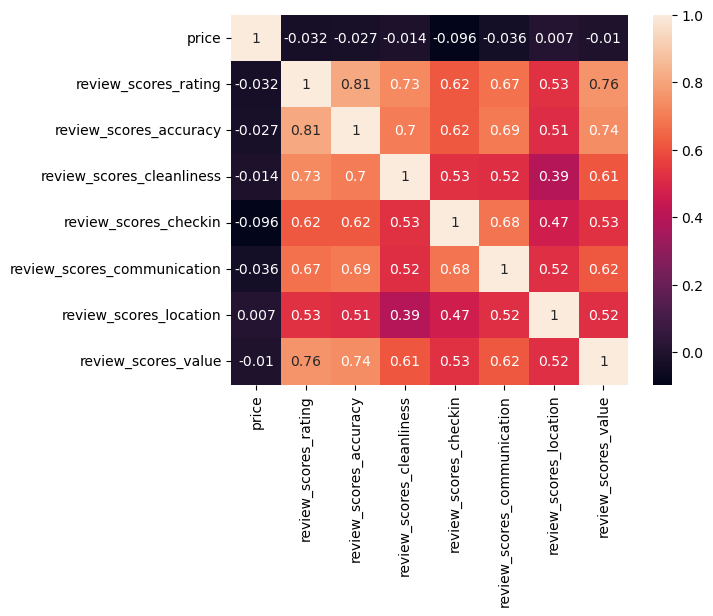

In [18]:
#Correlation map between individual review score metrics
df_price_reviews.corr()
sns.heatmap(df_price_reviews.corr(), annot = True)
plt.rcParams['figure.figsize'] = (20,7)
plt.show()

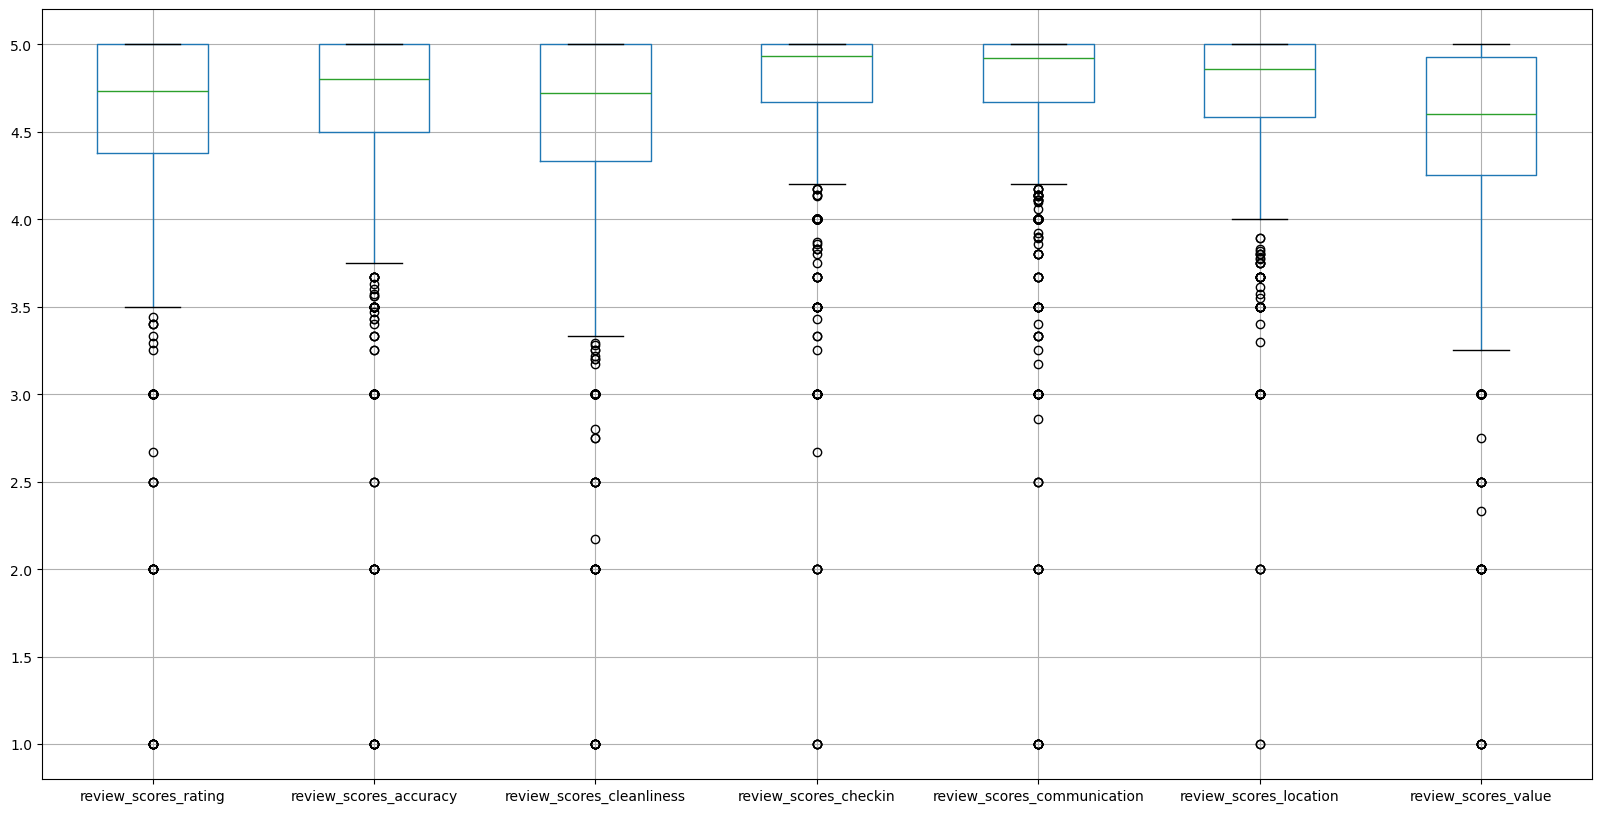

In [19]:
df_price_reviews.drop(columns='price').boxplot(figsize=(20,10))
plt.show()

In [21]:
#Dataframes with metrics grouped by room type
df_listings.groupby(by='room_type')['listing_id'].count().sort_values(ascending=False)

room_type
Private room       1708
Entire home/apt    1574
Shared room         159
Hotel room           99
Name: listing_id, dtype: int64

In [68]:
df_listings['property_type'].unique()

array(['villa', 'home', 'rental unit', 'Private room', 'townhouse',
       'condo', 'earthen home', 'bed and breakfast', 'hostel',
       'aparthotel', 'loft', 'serviced apartment', 'bungalow', 'place',
       'guesthouse', 'vacation home', 'hotel', 'guest suite',
       'Shared room', 'boutique hotel', 'Tiny home', 'Campsite', 'Boat',
       'casa particular', 'riad', 'barn', 'resort', 'cabin', 'Tower',
       'castle'], dtype=object)

In [67]:
df_listings[df_listings['property_type'].str.lower().str.contains('bungalow', na=False)]

,listing_id,host_id,host_location,host_country,host_continent,host_neighbourhood,neighbourhood,neighbourhood_group,latitude,longitude,property_type,room_type,accommodates,bathrooms,bathroom_type,bedrooms,beds,amenities,price,number_of_reviews,review_scores_rating,review_scores_accuracy,review_scores_cleanliness,review_scores_checkin,review_scores_communication,review_scores_location,review_scores_value
123,5573458,28809566,Singapore,Singapore,Asia,NaN,Sembawang,North,1.44,103.82,bungalow,Private room,2,1.00,Private,1.00,1.00,"[""Essentials"", ""Air conditioning"", ""Hot water""...",204.00,3,5.00,4.67,5.00,5.00,5.00,5.00,5.00
144,6603464,28809566,Singapore,Singapore,Asia,NaN,Sembawang,North,1.44,103.82,bungalow,Private room,2,1.00,Private,1.00,1.00,"[""Essentials"", ""Air conditioning"", ""Hot water""...",134.00,9,4.44,4.33,4.78,4.78,4.78,4.67,4.67
196,8256942,28809566,Singapore,Singapore,Asia,NaN,Sembawang,North,1.44,103.82,bungalow,Private room,2,1.00,Private,1.00,1.00,"[""Air conditioning"", ""Heating"", ""Wifi""]",107.00,6,4.00,3.50,4.00,4.67,4.67,3.67,3.33
267,10210475,28809566,Singapore,Singapore,Asia,NaN,Sembawang,North,1.44,103.82,bungalow,Private room,2,1.00,Private,1.00,NaN,"[""Essentials"", ""TV"", ""Air conditioning"", ""Iron...",NaN,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
292,11660178,24496358,Singapore,Singapore,Asia,Katong,Bedok,East,1.32,103.92,bungalow,Private room,4,1.00,Private,1.00,2.00,"[""Free parking on premises"", ""Air conditioning...",200.00,6,4.83,4.83,4.83,5.00,5.00,4.83,4.50
293,11679272,24496358,Singapore,Singapore,Asia,Katong,Bedok,East,1.32,103.91,bungalow,Private room,3,1.00,Private,1.00,1.00,"[""Free parking on premises"", ""Air conditioning...",180.00,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
334,13183241,24496358,Singapore,Singapore,Asia,Katong,Bedok,East,1.33,103.91,bungalow,Private room,3,1.00,Shared,1.00,2.00,"[""Free parking on premises"", ""Air conditioning...",160.00,3,5.00,5.00,5.00,5.00,5.00,5.00,4.50
368,14158971,24496358,Singapore,Singapore,Asia,Katong,Bedok,East,1.33,103.92,bungalow,Private room,2,1.00,Private,1.00,1.00,"[""Washer"", ""Free parking on premises"", ""Essent...",130.00,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
382,14558461,24496358,Singapore,Singapore,Asia,Katong,Bedok,East,1.32,103.92,bungalow,Private room,3,1.00,Shared,1.00,2.00,"[""Free parking on premises"", ""Air conditioning...",170.00,1,5.00,5.00,5.00,5.00,5.00,5.00,5.00
404,15365213,24496358,Singapore,Singapore,Asia,Katong,Bedok,East,1.33,103.92,bungalow,Private room,2,1.00,Private,1.00,1.00,"[""Free parking on premises"", ""Air conditioning...",130.00,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [23]:
df_listings.groupby(by='room_type')[['review_scores_rating', 'review_scores_accuracy', 'review_scores_cleanliness', 'review_scores_checkin', 'review_scores_communication',
                                     'review_scores_location', 'review_scores_value']].mean().sort_values(by='review_scores_rating', ascending=False)

,review_scores_rating,review_scores_accuracy,review_scores_cleanliness,review_scores_checkin,review_scores_communication,review_scores_location,review_scores_value
room_type,,,,,,,
Entire home/apt,4.68,4.69,4.73,4.80,4.79,4.75,4.51
Private room,4.55,4.59,4.45,4.76,4.74,4.70,4.47
Hotel room,4.37,4.49,4.42,4.71,4.60,4.69,4.41
Shared room,4.26,4.41,4.27,4.60,4.56,4.59,4.29


In [58]:
#Bar graph to visualise the average price based on neighbourhood group and room type
df_listings.groupby(by=['room_type', 'neighbourhood_group'])['price'].mean().sort_values(ascending=False)

room_type        neighbourhood_group
Shared room      Central               824.20
Entire home/apt  Central               367.91
                 North-East            343.05
                 East                  334.04
                 West                  321.14
                 North                 261.86
Hotel room       Central               176.03
Shared room      North-East            130.00
Private room     Central               120.08
                 East                  108.26
Shared room      North                 102.00
                 East                  100.00
                 West                   96.60
Private room     West                   90.48
                 North-East             86.70
                 North                  83.81
Name: price, dtype: float64

In [25]:
df_listings.groupby('room_type').agg({'price': ['min','max','count'], 'review_scores_rating': ['mean','count']})

price               review_scores_rating      
                  min     max count                 mean count
room_type                                                     
Entire home/apt 38.00 5000.00  1389                 4.68   667
Hotel room      27.00  296.00    33                 4.37    95
Private room    19.00 4000.00  1210                 4.55   937
Shared room     24.00 9999.00   127                 4.26   106

In [59]:
df_index = df_listings.groupby(by=['room_type', 'neighbourhood_group'])['price'].mean().sort_values(ascending=False)
df_index

room_type        neighbourhood_group
Shared room      Central               824.20
Entire home/apt  Central               367.91
                 North-East            343.05
                 East                  334.04
                 West                  321.14
                 North                 261.86
Hotel room       Central               176.03
Shared room      North-East            130.00
Private room     Central               120.08
                 East                  108.26
Shared room      North                 102.00
                 East                  100.00
                 West                   96.60
Private room     West                   90.48
                 North-East             86.70
                 North                  83.81
Name: price, dtype: float64

In [60]:
df_index.sort_index(ascending=[True, False], inplace=True)
df_index

room_type        neighbourhood_group
Entire home/apt  West                  321.14
                 North-East            343.05
                 North                 261.86
                 East                  334.04
                 Central               367.91
Hotel room       Central               176.03
Private room     West                   90.48
                 North-East             86.70
                 North                  83.81
                 East                  108.26
                 Central               120.08
Shared room      West                   96.60
                 North-East            130.00
                 North                 102.00
                 East                  100.00
                 Central               824.20
Name: price, dtype: float64

In [61]:
df_index = df_index.reset_index()

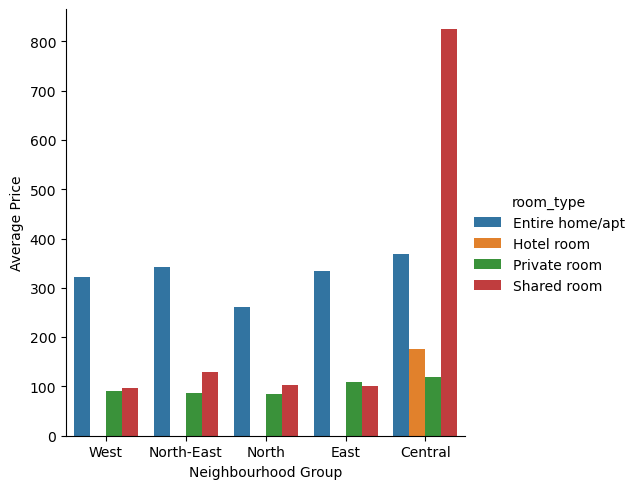

In [62]:
bar_plot = sns.catplot(x='neighbourhood_group', y='price', hue='room_type', data=df_index, kind='bar')
bar_plot.set_axis_labels('Neighbourhood Group', 'Average Price')
bar_plot.set_titles('Average Price Per Neighbourhood Group Per Room Type')
plt.rcParams['figure.figsize'] = (20,7)
plt.show()

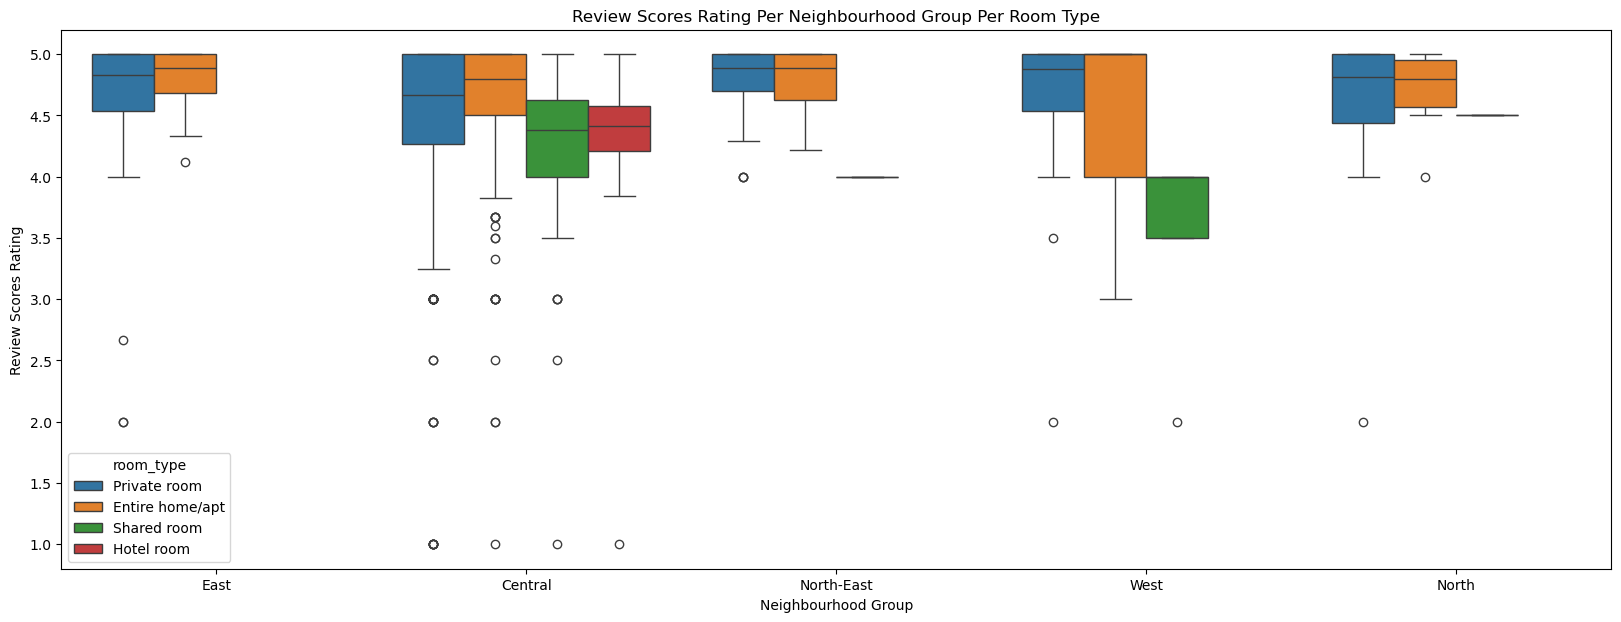

In [63]:
#Box plot to visualise the distrbution of review scores
box_plot = sns.boxplot(data=df_listings, x='neighbourhood_group', y ='review_scores_rating', hue='room_type')
box_plot.set_title('Review Scores Rating Per Neighbourhood Group Per Room Type')
box_plot.set_xlabel('Neighbourhood Group')
box_plot.set_ylabel('Review Scores Rating')
plt.rcParams['figure.figsize'] = (20,7)
plt.show()